In [1]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
#import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cfeature

import easygems.healpix as egh
import healpy as hp

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob

In [2]:
import dask
from dask.distributed import Client
import multiprocessing

ncpu = multiprocessing.cpu_count()
threads = 8
nworker = ncpu // threads
print(
    f"Number of CPUs: {ncpu}, number of threads: {threads}, number of workers: {nworker}"
)
client = Client(
    processes=True, threads_per_worker=threads, n_workers=nworker, memory_limit="100GB"
)
client 

Number of CPUs: 256, number of threads: 8, number of workers: 32


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 256,Total memory: 2.91 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36159,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45377,Total threads: 8
Dashboard: http://127.0.0.1:41907/status,Memory: 93.13 GiB
Nanny: tcp://127.0.0.1:43943,


In [3]:
import dask # Distributed data libary
import dask.distributed
import multiprocessing
from subprocess import run, PIPE
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})

# basic
from pathlib import Path # Object oriented libary to deal with paths
from dask.utils import format_bytes
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources

# Functions

In [4]:
import matplotlib.colors as mcolors
def plot_map_healpix(da, ax=None, title=None, colorbar=True, cmap="viridis", nest=True, vmin=None, vmax=None, space=None, extend=None, label=None, latmin=-90, latmax=90, lonmin=-180, lonmax=180):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    
    if not ax:
        projection = ccrs.PlateCarree(central_longitude=225)
        fig, ax = plt.subplots(
            subplot_kw={"projection": projection}, constrained_layout=True, figsize=(15, 10)
        )
    ax.set_extent([lonmin, lonmax, latmin, latmax], ccrs.PlateCarree())
    ax.coastlines()
    ax.set_title(title)
    
    # Use the range values if provided
    norm = None
    if vmin is not None and vmax is not None:
        norm = plt.Normalize(vmin, vmax)
        norm = mcolors.BoundaryNorm(np.linspace(vmin, vmax, space), cmap.N, extend=extend)

    pc = egh.healpix_show(da, ax=ax, cmap=cmap, norm=norm, nest=nest)
    
    if colorbar:
        #cbar = fig.colorbar(pc, ax=ax, orientation="horizontal", pad=0.05)
        bounds = np.linspace(vmin,vmax,space)
        pc.set_clim(vmin, vmax)
        cb = plt.colorbar(pc, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend,ticks=bounds, boundaries=bounds)
        cb.ax.set_facecolor('none')
        cb.set_label(label=label, size=15, weight='bold')
        cb.ax.tick_params(labelsize=20)
        cb.ax.set_xticklabels(bounds,rotation=270)
       # if levels is not None:
       #      cbar.set_ticks(levels)
    kw = {'levels':[-1], 'colors':['red'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                      ax=ax,
                      transform=ccrs.PlateCarree(),
                      **kw
                     )
    
    _ = fig.subplots_adjust(left=0.01, right=0.98, hspace=0, wspace=0, top=0.9, bottom=0.25)
    return pc

In [5]:
def plot_monthly_maps(da, cmap="viridis", nest=True, vmin=None, vmax=None, space=None, extend=None, label=None,
                      latmin=-90, latmax=90, lonmin=-180, lonmax=180):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES

    fig, axes = plt.subplots(3, 4, figsize=(20, 25), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=225)})

    for i, ax in enumerate(axes.flat):
        month_data = da.sel(month = (i + 1))  # Select and average each month

        ax.set_extent([lonmin, lonmax, latmin, latmax], ccrs.PlateCarree())
        ax.coastlines()
        ax.set_title(f"Month {i+1}", fontsize=15, weight='bold')

        # Normalize color scale
        norm = plt.Normalize(vmin, vmax) if vmin is not None and vmax is not None else None

        # Plot data
        pc = egh.healpix_show(month_data, ax=ax, cmap=cmap, norm=norm, nest=nest)

        # Add Amazon biome contour
        kw = {'levels': [-1], 'colors': ['red'], 'linestyles': ['solid']}
        AMZ_BD.plot.contour(ax=ax, transform=ccrs.PlateCarree(), **kw)

    # Add colorbar
    cb_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  # Colorbar position
    bounds = np.linspace(vmin, vmax, space) if space else None
    cb = plt.colorbar(pc, cax=cb_ax, orientation="horizontal", extend=extend, ticks=bounds, boundaries=bounds)
    cb.set_label(label=label, size=20, weight='bold')
    cb.ax.tick_params(labelsize=15)

    plt.tight_layout()
    plt.show()


In [6]:
def plot_map_scatter(da, title=None, colorbar=True, cmap="viridis", s=50, nest=True, vmin=None, vmax=None, space=None, extend='both', latmin=-20, latmax=20, lonmin=-80, lonmax=-40):
        dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
        AMZ_BD = dset_bd.AMAZON_BIOMES

        projection = ccrs.PlateCarree(central_longitude=225)
        coords = projection.transform_points(ccrs.Geodetic(),
                np.rad2deg(da.lon.values),np.rad2deg(da.lat.values)) 

        fig, ax = plt.subplots(figsize=(15,10),subplot_kw={'projection':projection}, constrained_layout=True)
        ax.set_extent([lonmin, lonmax, latmin, latmax], ccrs.PlateCarree())
        ax.coastlines()
        ax.set_title(title)

        ax.add_feature(cfeature.COASTLINE,linewidth=1.0,color='black')
        im = plt.scatter(da.lon, da.lat, c=da, s=s, cmap=cmap, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)

        bounds = np.linspace(vmin,vmax,space)
        cb = plt.colorbar(im, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend, ticks=bounds, boundaries=bounds)
        cb.set_label(label='mm/day', size=15, weight='bold')
        cb.ax.tick_params(labelsize=20)
        cb.ax.set_xticklabels(bounds,rotation=270)
        kw = {'levels':[-1], 'colors':['red'], 'linestyles':['solid']}
        plot_bd = AMZ_BD.plot.contour( 
                        ax=ax,
                        transform=ccrs.PlateCarree(),
                        **kw
                        )
        _ = fig.subplots_adjust(left=0.01, right=0.98, hspace=0, wspace=0, top=0.9, bottom=0.25)

In [7]:
def mask_cal(dset):
    ##This function calculate the land_sea mask according to the resolution of the data##
    ###negative values is ocean, positive values is land
    filemask = '/work/mh0731/from_Mistral/mh0731/m300876/land_sea_mask/GPM_IMERG_LandSeaMask.2.nc4'
    dsetmask = xr.open_dataset(filemask)
    lsmask01 = dsetmask.landseamask.where(
        dsetmask.landseamask<100).interp(lon=dset.lon.values,lat=dset.lat.values,method='linear') *0 +2
    lsmask01 = lsmask01.where(lsmask01==2,-2)
    return lsmask01

In [8]:
def get_amazon_index(nside=12**2, nest=True):
    amazon = xr.open_dataset(
        "/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc"
    ).stack(cell=("latitude", "longitude"))
    
    is_amazon = amazon.where(amazon.AMAZON_BIOMES == 0, drop=True)
    
    return np.unique(hp.ang2pix(nside, is_amazon.longitude.values, is_amazon.latitude.values, nest=nest, lonlat=True)).astype(int)


In [9]:
def time_mean_imerg_multi(file,lat,lon,environ):
    ##Funtion to calculate the climatology monthly mean of precipitation from IMERG
    ###the environ option mask the values over land or ocean:
        ## if environ = 'trop' -> no mask is used
        ## if environ = 'ocean' -> return only values over ocean
        ## if environ = 'land' -> return only values over land
    data = xr.open_mfdataset(
        file, combine='by_coords',engine='netcdf4',chunks=({'time':20}))['calibrated_precipitation']
    if environ == 'trop':
        pr=data.sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
    else:
        lsmask01 = mask_cal(data)
        if environ == 'ocean':
            pr=data.where(lsmask01<0).sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
        elif environ == 'land':
            pr=data.where(lsmask01>0).sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
        else:
            return print('Something is wrong')
    
    prmon = pr.resample(time='1MS').mean(dim='time')
    prmon_clim = prmon.groupby('time.month').mean(dim='time')
    
    jobs = dask.persist(prmon) # prmon_clim (month, lat, lon) for the mean/ prmon (year, month, lat, lon) for the std
    progress(jobs, notebook=False)
    precip = dask.compute(prmon) # prmon_clim
    
    return precip[0]

In [10]:
def colormap_create(cmap, cnumber, loc_boundary_low, loc_boundary_high):
    get_cmap = cm.get_cmap(cmap,cnumber) 
    cmap_edit = get_cmap(np.linspace(0,1,cnumber))
    white = np.array([255/256, 255/256, 255/256, 1])
    cmap_edit[loc_boundary_low:loc_boundary_high] = white
    cmap_new = matplotlib.colors.ListedColormap(cmap_edit)
    return cmap_new

In [11]:
# IFS
def samerica(ds):
     return (ds.lat >= -60) & (ds.lat <= 20) & (ds.lon >= 260) & (ds.lon <= 340)
def amazon(ds):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    AMZ_BD['longitude'] = (AMZ_BD['longitude'] + 360) % 360 # change from -180-180 to 0-360
    grid_amz = AMZ_BD.interp(latitude=ds.lat, longitude=ds.lon)
    return (ds.lat >= -30) & (ds.lat <= 20) & (ds.lon >= 270) & (ds.lon <= 330) & (grid_amz==0)

In [12]:
BrBG_new = colormap_create('BrBG',21,10,11)
YlOrRd_new = colormap_create('YlOrRd',21,0,1)

# Load datasets

### AMIP

In [13]:
# ICON CTL (5km)
import intake
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
data_ctl  = cat['ICON.C5.AMIP_CNTL'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1997 (19 years) original: zoom8

In [14]:
dx_p4k  = cat['ICON.C5.AMIP_P4K'](time="P1D", zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1993 (15 years)

In [15]:
dx_4co2 = cat['ICON.C5.AMIP_4CO2'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1980-1994 (15 years)

In [16]:
# ICON-amip
dx_ctl = data_ctl.sel(time=slice("1980", "1994")) 
dx_p4k = dx_p4k.sel(time=slice("1979", "1993"))
dx_4co2 = dx_4co2.sel(time=slice("1980", "1994"))

In [24]:
print(dx_ctl.tas.mean(dim=('cell','time')).values)
print(dx_4co2.tas.mean(dim=('cell','time')).values)
print(dx_p4k.tas.mean(dim=('cell','time')).values)

286.55502
287.10345
290.96625


### ICON NGC

In [17]:
# NGC4
dx_ngc = cat.ICON.ngc4008(zoom=8).to_dask().pipe(egh.attach_coords)

In [18]:
dx_ngc_start = dx_ngc.sel(time=slice('2024-01-01', '2028-12-31')) # 5 years
dx_ngc_end = dx_ngc.sel(time=slice('2045-01-01', '2049-12-31')) # 5years

In [18]:
dx_ngc_start.tas.mean(dim=('time','cell'))

<xarray.DataArray 'tas' ()> Size: 4B
array(286.94406, dtype=float32)
Coordinates:
    crs      int64 8B 0

In [19]:
dx_ngc_end.tas.mean(dim=('time','cell'))

<xarray.DataArray 'tas' ()> Size: 4B
array(287.75397, dtype=float32)
Coordinates:
    crs      int64 8B 0

### IMERG

In [19]:
#Define a global pattern to find the files
glob_pattern_3d1 = 'IMERG_precipitationrate_V06B_daily_0.1degree_tropics_30S_30N_'
## Define the paths
data_path1 = Path('/work/mh0731/from_Mistral/mh0731/m300876/precip_paper/data/obs/IMERG')
## Collect all file names with pathlib's rglob and list compression  
file_imerg = sorted([str(f) for f in data_path1.rglob(f'*{glob_pattern_3d1}*.nc')])[:]

In [20]:
imerg_mult_SA_int= time_mean_imerg_multi(file_imerg,[-30,13],[-82,-30],'land') 

## Only Amazon

In [19]:
is_amazon = get_amazon_index(nside=egh.get_nside(data_ctl))
dx_ctl_amz = data_ctl.isel(cell=is_amazon).sel(time=slice("1980", "1994"))  # 1979-1997
dx_p4k_amz = dx_p4k.isel(cell=is_amazon).sel(time=slice("1979", "1993")) # 1979-1993
dx_4co2_amz = dx_4co2.isel(cell=is_amazon).sel(time=slice("1980", "1994")) # 1980-1994

In [22]:
# NGC4
is_amazon_ngc = get_amazon_index(nside=egh.get_nside(dx_ngc))
dx_ngc_start_amz = dx_ngc_start.isel(cell=is_amazon_ngc)
dx_ngc_end_amz = dx_ngc_end.isel(cell=is_amazon_ngc)

In [23]:
# IMERG
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome_imerg = AMZ_BD.interp(latitude=imerg_mult_SA_int.lat, longitude=imerg_mult_SA_int.lon)
imerg_mult_amz = imerg_mult_SA_int.where(ABinterp_biome_imerg==0, np.nan).sel(lon=slice(-82,-30), lat=slice(-30,13))
imerg_pr_amz_savg = imerg_mult_amz.mean(("lon", "lat"))

## Precipitation

In [ ]:
print(dx_ctl_amz.pr.mean(dim=('time','cell')).values * 86400)
print(dx_ngc_start_amz.pr.mean(dim=('time','cell')).values * 86400)
#print(pr_ifs_start_amz.mean(dim=('month','value')).values)

6.727434089407325
4.7639781958423555


In [19]:
print(dx_p4k_amz.pr.mean(dim=('time','cell')).values * 86400)
print(dx_4co2_amz.pr.mean(dim=('time','cell')).values * 86400)
print(dx_ngc_end_amz.pr.mean(dim=('time','cell')).values * 86400)

6.862535700201988
6.999154854565859
4.468051856383681


In [23]:
#print(dx_ctl_amz.tas.mean(dim=('time','cell')).values )
#print(dx_p4k_amz.tas.mean(dim=('time','cell')).values )
#print(dx_4co2_amz.tas.mean(dim=('time','cell')).values )
print(dx_ngc_start_amz.tas.mean(dim=('time','cell')).values )
print(dx_ngc_end_amz.tas.mean(dim=('time','cell')).values)

297.68088
298.75928


In [32]:
p4k_pr_amz_percentage = ((dx_p4k_amz.pr.mean(dim=('time','cell')) - dx_ctl_amz.pr.mean(dim=('time','cell'))) / dx_ctl_amz.pr.mean(dim=('time','cell'))) * 100
co2_pr_amz_percentage = ((dx_4co2_amz.pr.mean(dim=('time','cell')) - dx_ctl_amz.pr.mean(dim=('time','cell'))) / dx_ctl_amz.pr.mean(dim=('time','cell'))) * 100
print(p4k_pr_amz_percentage.values)
print(co2_pr_amz_percentage.values)

2.008219
4.0389957


In [74]:
a = (dx_p4k_amz.pr.mean(dim=('time','cell')) - dx_ctl_amz.pr.mean(dim=('time','cell'))) * 86400
b = (dx_4co2_amz.pr.mean(dim=('time','cell')) - dx_ctl_amz.pr.mean(dim=('time','cell'))) * 86400
print(a.values, b.values)

0.13510161079466343 0.27172076515853405


In [29]:
print((4.47-4.76)/4.76 * 100) # P4K

-6.092436974789917


In [31]:
icon_pr_amz_percentage = ((dx_ngc_end_amz.pr.mean(dim=('time','cell')) - dx_ngc_start_amz.pr.mean(dim=('time','cell')))) / dx_ngc_start_amz.pr.mean(dim=('time','cell')) * 100
#ifs_pr_amz_percentage = ((pr_ifs_end_amz.mean(dim=('month','value')) - pr_ifs_start_amz.mean(dim=('month','value'))) / pr_ifs_start_amz.mean(dim=('month','value'))) * 100
print(icon_pr_amz_percentage.values)
#print(ifs_pr_amz_percentage.values)

-6.211748346686363


In [83]:
a = ((dx_ngc_end_amz.pr.mean(dim=('time','cell')) - dx_ngc_start_amz.pr.mean(dim=('time','cell')))) * 86400
b = ((pr_ifs_end_amz.mean(dim=('month','value')) - pr_ifs_start_amz.mean(dim=('month','value'))))
print(a.values, b.values)

-0.29592602513730526 -0.43317799827595227


## Precipitation

In [24]:
# control amip 30 years
ctl_std = np.array([1.802019,1.089729,0.885105,0.508578,0.684973,0.420482,0.389199,0.305718,0.541051,0.476217,0.513375,0.334840])

### variability from AMIP

In [25]:
pr_ctl_amz_mon_mean = dx_ctl_amz.pr.mean('cell').resample(time="1M").mean().groupby("time.month").mean("time") * 86400
pr_ctl_amz_mon_std = dx_ctl_amz.pr.mean('cell').resample(time="1M").mean().groupby("time.month").std("time") * 86400

In [26]:
pr_4co2_amz_mon_mean = dx_4co2_amz.pr.mean('cell').resample(time="1M").mean().groupby("time.month").mean("time") * 86400
pr_4co2_amz_mon_std = dx_4co2_amz.pr.mean('cell').resample(time="1M").mean().groupby("time.month").std("time") * 86400

In [27]:
pr_p4k_amz_mon_mean = dx_p4k_amz.pr.mean('cell').resample(time="1M").mean().groupby("time.month").mean("time") * 86400
pr_p4k_amz_mon_std = dx_p4k_amz.pr.mean('cell').resample(time="1M").mean().groupby("time.month").std("time") * 86400

_ngc_

In [28]:
pr_ngcb_amz_mon_mean = dx_ngc_start_amz.pr.mean('cell').resample(time="1M").mean().groupby("time.month").mean("time") * 86400
pr_ngcb_amz_mon_std = dx_ngc_start_amz.pr.mean('cell').resample(time="1M").mean().groupby("time.month").std("time") * 86400

In [29]:
pr_ngce_amz_mon_mean = dx_ngc_end_amz.pr.mean('cell').resample(time="1M").mean().groupby("time.month").mean("time") * 86400
pr_ngce_amz_mon_std = dx_ngc_end_amz.pr.mean('cell').resample(time="1M").mean().groupby("time.month").std("time") * 86400

_IMERG_

In [30]:
imerg_pr_amz_savg_1m = imerg_pr_amz_savg.resample(time='1M').mean("time")
imerg_pr_amz_savg_clima = imerg_pr_amz_savg_1m.groupby('time.month').mean('time')
imerg_pr_amz_savg_std = imerg_pr_amz_savg_1m.groupby('time.month').std('time')

In [38]:
print(imerg_pr_amz_savg_clima)
print(imerg_pr_amz_savg_std)

<xarray.DataArray 'calibrated_precipitation' (month: 12)> Size: 48B
array([8.079559 , 8.779849 , 9.052007 , 8.53396  , 7.5231285, 5.7371216,
       4.63798  , 3.7799993, 3.9687765, 5.154591 , 6.165588 , 7.5521355],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
<xarray.DataArray 'calibrated_precipitation' (month: 12)> Size: 48B
array([1.2331072 , 0.8961133 , 0.78742063, 0.59476167, 0.4721563 ,
       0.49181667, 0.3091551 , 0.3592443 , 0.43029553, 0.6207369 ,
       0.6878885 , 0.958658  ], dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12


## 1. Mean features: Map, Time series, PDF

### Mean and STD

_annual mean_

In [31]:
pr_ctl_amz_avg = pr_ctl_amz_mon_mean.mean('month')
pr_p4k_amz_avg = pr_p4k_amz_mon_mean.mean('month')
pr_4co2_amz_avg = pr_4co2_amz_mon_mean.mean('month')

In [32]:
pr_ngcs_amz_avg = pr_ngcb_amz_mon_mean.mean('month')
pr_ngce_amz_avg = pr_ngce_amz_mon_mean.mean('month')

In [33]:
print((4.4690886192256585 - 4.764368163887411)/4.764368163887411*100)
print((4.960569418969638 - 5.393747417245592)/5.393747417245592*100)

-6.197664296808334
-8.031113894783818


In [31]:
print(pr_ctl_amz_avg.values, pr_p4k_amz_avg.values, pr_4co2_amz_avg.values)

6.736295385053381 6.872391665820032 7.009252009447664


In [35]:
print((6.872391665820032-6.736295385053381)/6.736295385053381*100)
print((7.009252009447664-6.736295385053381)/6.736295385053381*100)

2.020343126113858
4.0520287308054215


In [26]:
print(pr_ngcs_amz_avg.values, pr_ngce_amz_avg.values)

4.764368163887411 4.4690886192256585


In [26]:
pr_ctl_amz_mon_std.values.mean()

np.float32(0.4582608)

In [34]:
pr_ngcb_amz_mon_std.values.mean()

np.float32(0.4898466)

In [41]:
imerg_pr_amz_savg_clima.values.mean()

np.float32(6.5803924)

In [42]:
imerg_pr_amz_savg_std.values.mean()

np.float32(0.6534462)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

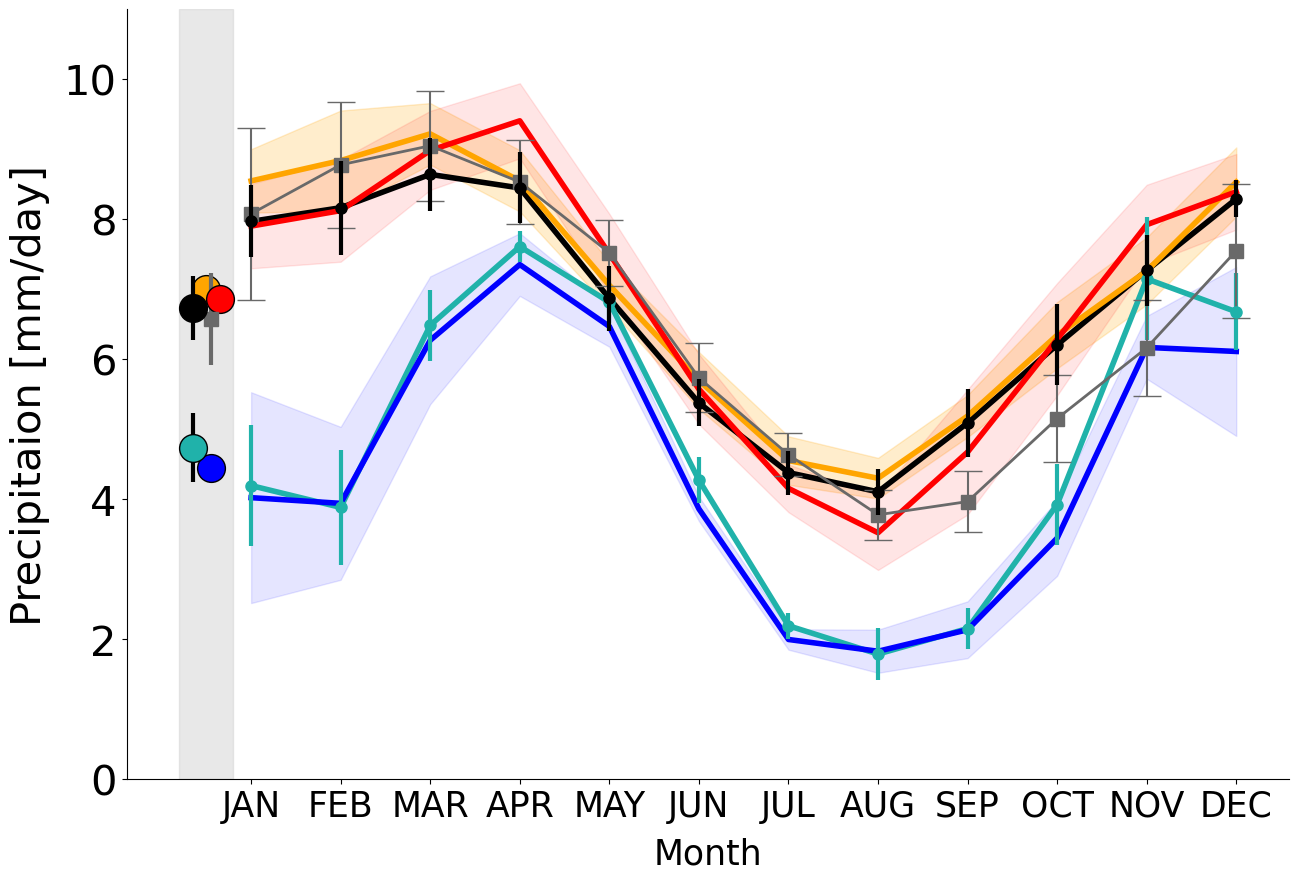

In [35]:
fig, ax = plt.subplots(figsize=(15,10))

# AMIP
pr_ctl_amz_mon_mean.plot(c='black',linewidth=4)
pr_4co2_amz_mon_mean.plot(c='orange',linewidth=4) #short time
pr_p4k_amz_mon_mean.plot(c='red',linewidth=4) # long time
# NGC4
pr_ngcb_amz_mon_mean.plot(c='lightseagreen',linewidth=4) # long time
pr_ngce_amz_mon_mean.plot(c='blue',linewidth=4) # long time
# IMERG
imerg_pr_amz_savg_clima.plot(c='dimgray', linewidth=2)

# standard deviation
ctl_mean = pr_ctl_amz_mon_mean.values
ctl_std = pr_ctl_amz_mon_std.values
co2_mean = pr_4co2_amz_mon_mean.values
co2_std = pr_4co2_amz_mon_std.values
p4k_mean = pr_p4k_amz_mon_mean.values
p4k_std = pr_p4k_amz_mon_std.values

ngcs_mean = pr_ngcb_amz_mon_mean.values
ngcs_std = pr_ngcb_amz_mon_std.values
ngce_mean = pr_ngce_amz_mon_mean.values
ngce_std = pr_ngce_amz_mon_std.values

imerg_mean = imerg_pr_amz_savg_clima.values
imerg_std = imerg_pr_amz_savg_std.values

plt.errorbar(pr_ctl_amz_mon_mean.month, ctl_mean, ctl_std, linestyle='None', marker='o', markersize='8', linewidth=3, c='black', zorder=15)
plt.fill_between(pr_ctl_amz_mon_mean.month, co2_mean-co2_std, co2_mean+co2_std, color='orange', alpha=0.2)
plt.fill_between(pr_ctl_amz_mon_mean.month, p4k_mean-p4k_std, p4k_mean+p4k_std, color='red', alpha=0.1)

#plt.fill_between(pr_ctl_amz_mon_mean.month, ngcs_mean-ngcs_std, ngcs_mean+ngcs_std, color='lightseagreen', alpha=0.2)
plt.errorbar(pr_ctl_amz_mon_mean.month, ngcs_mean, ngcs_std, linestyle='None', marker='o', markersize='8', linewidth=3, c='lightseagreen')
plt.fill_between(pr_ctl_amz_mon_mean.month, ngce_mean-ngce_std, ngce_mean+ngce_std, color='blue', alpha=0.1)

plt.errorbar(pr_ctl_amz_mon_mean.month, imerg_mean[:], yerr=imerg_std[:], fmt='s', color='dimgray', ecolor='dimgray', capsize=10,  markersize='10',label='IMERG')

#plt.scatter(1,6.98, c=right, marker='o', s=150)
plt.errorbar(0.5,7.00,yerr=0, c='orange', marker='o', markeredgecolor='black', markersize='20', zorder=1)
plt.errorbar(0.65,6.86,yerr=0, c='red', marker='o', markeredgecolor='black', markersize='20', zorder=2)
plt.errorbar(0.35,6.73,yerr=0.4582608, c='black', ecolor='black', marker='o', markersize='20', markeredgecolor='black', linewidth=3, zorder=10) #, s=150) # CTL with Climatology error bar

plt.errorbar(0.35,4.74,yerr=0.4898466, c='lightseagreen', ecolor='black', marker='o', markeredgecolor='black', markersize='20', linewidth=3, zorder=12)
plt.errorbar(0.55,4.45,yerr=0, c='blue', marker='o', markeredgecolor='black', markersize='20')
#plt.errorbar(0.5,5.23,yerr=0, c='lightcoral', marker='o', markeredgecolor='black', markersize='20')
#plt.errorbar(0.5,4.96,yerr=0, c='darkred', marker='o', markeredgecolor='black', markersize='20')

plt.errorbar(0.55,6.58,yerr=0.6534462, c='dimgray', marker='s', markeredgecolor='dimgray', markersize='10', linewidth=3)

#plt.axvline(x=0.2, ymin=0.4, ymax=0.7, color='black', linestyle='--', linewidth=2)
#plt.axvline(x=0.8, ymin=0.4, ymax=0.7, color='black', linestyle='--', linewidth=2)
ax.axvspan(0.2, 0.8, alpha=0.5, color='lightgrey')

#plt.xticks(fontsize=30)
plt.yticks(fontsize=30,family='Arial')
ax.set_ylabel('Precipitaion [mm/day]',fontsize=30, labelpad = 10,family='Arial')
ax.set_xlabel('Month',fontsize=25, labelpad = 10)
#plt.xlabel('Difference PR [mm/day]',fontsize=25, labelpad = 20)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],fontsize=25,family='Arial')
plt.ylim(0,11)
ax.spines[['right', 'top']].set_visible(False)

#fig.savefig('./pr_exp.png', transparent=True)

## Different variables - SM

### Mean and std

In [123]:
var= 'hydro_w_soil_column_box'
var_icon = 'hydro_wtr_soil_sl_box' 
var_ifs='swvl1'

_AMIP_

In [ ]:
results = {}
results[f"{var}_ctl_amz_mon_mean"] = dx_ctl_amz[var_icon].mean('cell').resample(time="1M").mean().groupby("time.month").mean("time") 
results[f"{var}_4co2_amz_mon_mean"] = dx_4co2_amz[var_icon].mean('cell').resample(time="1M").mean().groupby("time.month").mean("time") 
results[f"{var}_p4k_amz_mon_mean"] = dx_p4k_amz[var_icon].mean('cell').resample(time="1M").mean().groupby("time.month").mean("time") 

In [107]:
results[f"{var}_ctl_amz_mon_std"] = dx_ctl_amz[var_icon].mean('cell').resample(time="1M").mean().groupby("time.month").std("time") 
results[f"{var}_4co2_amz_mon_std"] = dx_4co2_amz[var_icon].mean('cell').resample(time="1M").mean().groupby("time.month").std("time") 
results[f"{var}_p4k_amz_mon_std"] = dx_p4k_amz[var_icon].mean('cell').resample(time="1M").mean().groupby("time.month").std("time") 

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/groupby.py:668: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/groupby.py:668: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/groupby.py:668: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(


_NGC ICON_

In [124]:
# NGC4
results[f"{var}_ngcs_amz_month"] = dx_ngc_start_amz[var_icon].mean('cell').resample(time="1M").mean().groupby("time.month").mean("time")  
results[f"{var}_ngce_amz_month"] = dx_ngc_end_amz[var_icon].mean('cell').resample(time="1M").mean().groupby("time.month").mean("time")  

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/groupby.py:668: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/groupby.py:668: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(


In [125]:
# IFS
results[f"{var}_ifs_start_amz_month"] = dx_ifs_start_amz[var_ifs].mean('value').groupby("time.month").mean("time") 
results[f"{var}_ifs_end_amz_month"] = dx_ifs_end_amz[var_ifs].mean('value').groupby("time.month").mean("time") 
results[f"{var}_ifs_start_amz_month"] = results[f"{var}_ifs_start_amz_month"].roll(month=-1, roll_coords=False)
results[f"{var}_ifs_end_amz_month"] = results[f"{var}_ifs_end_amz_month"].roll(month=-1, roll_coords=False)

_annual mean_

In [110]:
ctl_amz_avg = results[f"{var}_ctl_amz_mon_mean"].mean('month')
p4k_amz_avg = results[f"{var}_p4k_amz_mon_mean"].mean('month')
co2_amz_avg = results[f"{var}_4co2_amz_mon_mean"].mean('month')

In [126]:
ngcs_amz_avg = results[f"{var}_ngcs_amz_month"].mean('month')
ngce_amz_avg = results[f"{var}_ngce_amz_month"].mean('month')

In [127]:
ifss_amz_avg = results[f"{var}_ifs_start_amz_month"].mean('month')
ifse_amz_avg = results[f"{var}_ifs_end_amz_month"].mean('month')

In [128]:
ngcs_amz_avg

<xarray.DataArray 'hydro_wtr_soil_sl_box' (soil_depth_water_level: 5)> Size: 20B
array([0.0114384 , 0.04912205, 0.1564356 , 0.15237443, 0.00730572],
      dtype=float32)
Coordinates:
  * soil_depth_water_level  (soil_depth_water_level) float32 20B 0.0325 ... 6...
    crs                     int64 8B 0

In [46]:
print(ngcs_amz_avg.isel(level_full=89).values, ngce_amz_avg.isel(level_full=89).values)

0.013101566 0.013191623


In [115]:
print(ifss_amz_avg.values, ifse_amz_avg.values)

51.41579090371021 53.55595597924627


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

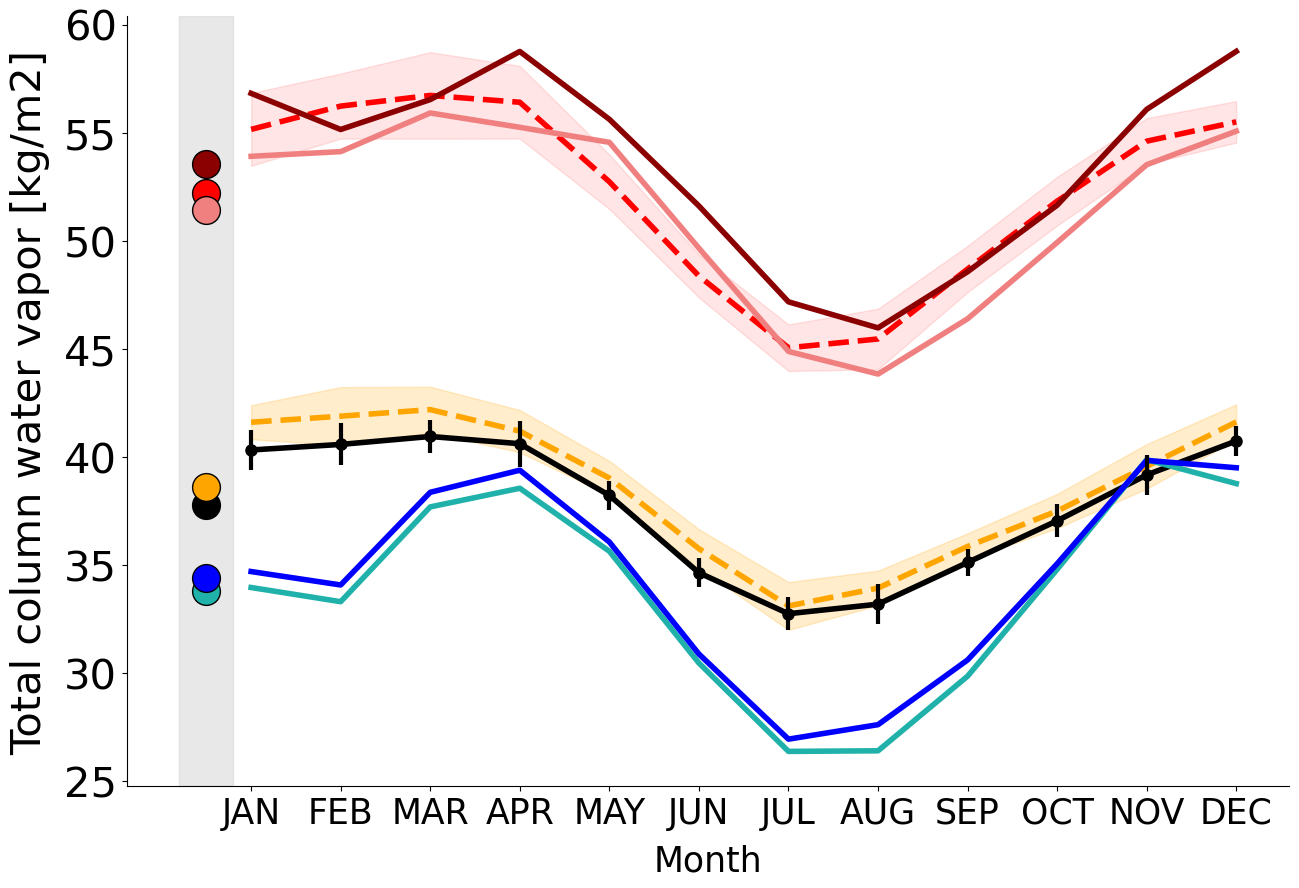

In [117]:
fig, ax = plt.subplots(figsize=(15,10))

# AMIP
results[f"{var}_ctl_amz_mon_mean"].plot(c='black',linewidth=4)
results[f"{var}_4co2_amz_mon_mean"].plot(c='orange',linewidth=4, ls='--') #short time
results[f"{var}_p4k_amz_mon_mean"].plot(c='red',linewidth=4, ls='--') # long time
# NGC4
results[f"{var}_ngcs_amz_month"].plot(c='lightseagreen',linewidth=4) # long time
results[f"{var}_ngce_amz_month"].plot(c='blue',linewidth=4) # long time
# IFS
results[f"{var}_ifs_start_amz_month"].plot(c='lightcoral',linewidth=4) # long time
results[f"{var}_ifs_end_amz_month"].plot(c='darkred',linewidth=4) # long time

# standard deviation
ctl_mean = results[f"{var}_ctl_amz_mon_mean"].values
ctl_std = results[f"{var}_ctl_amz_mon_std"].values
co2_mean = results[f"{var}_4co2_amz_mon_mean"].values
co2_std = results[f"{var}_4co2_amz_mon_std"].values
p4k_mean = results[f"{var}_p4k_amz_mon_mean"].values
p4k_std = results[f"{var}_p4k_amz_mon_std"].values
plt.errorbar(results[f"{var}_ctl_amz_mon_mean"].month, ctl_mean, ctl_std, linestyle='None', marker='o', markersize='8', linewidth=3, c='black')
plt.fill_between(results[f"{var}_ctl_amz_mon_mean"].month, co2_mean-co2_std, co2_mean+co2_std, color='orange', alpha=0.2)
plt.fill_between(results[f"{var}_ctl_amz_mon_mean"].month, p4k_mean-p4k_std, p4k_mean+p4k_std, color='red', alpha=0.1)

#plt.scatter(1,6.98, c=right, marker='o', s=150)
plt.errorbar(0.5,ctl_amz_avg.values,yerr=0, c='black', ecolor='black', marker='o', markersize='20', markeredgecolor='black', linewidth=3) #, s=150) # CTL with Climatology error bar
plt.errorbar(0.5,co2_amz_avg.values,yerr=0, c='orange', marker='o', markeredgecolor='black', markersize='20')
plt.errorbar(0.5,p4k_amz_avg.values,yerr=0, c='red', marker='o', markeredgecolor='black', markersize='20')
plt.errorbar(0.5,ngcs_amz_avg.values,yerr=0, c='lightseagreen', marker='o', markeredgecolor='black', markersize='20')
plt.errorbar(0.5,ngce_amz_avg.values,yerr=0, c='blue', marker='o', markeredgecolor='black', markersize='20')
plt.errorbar(0.5,ifss_amz_avg.values,yerr=0, c='lightcoral', marker='o', markeredgecolor='black', markersize='20')
plt.errorbar(0.5,ifse_amz_avg.values,yerr=0, c='darkred', marker='o', markeredgecolor='black', markersize='20')

#plt.axvline(x=0.2, ymin=0.4, ymax=0.7, color='black', linestyle='--', linewidth=2)
#plt.axvline(x=0.8, ymin=0.4, ymax=0.7, color='black', linestyle='--', linewidth=2)
ax.axvspan(0.2, 0.8, alpha=0.5, color='lightgrey')

#plt.xticks(fontsize=30)
plt.yticks(fontsize=30,family='Arial')
ax.set_ylabel('Total column water vapor [kg/m2]',fontsize=30, labelpad = 10,family='Arial')
ax.set_xlabel('Month',fontsize=25, labelpad = 10)
#plt.xlabel('Difference tas [mm/day]',fontsize=25, labelpad = 20)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],fontsize=25,family='Arial')
#plt.ylim(290,310)
ax.spines[['right', 'top']].set_visible(False)

#fig.savefig('./tas_exp.png', transparent=True)

## 2. Moisture balance equation

In [19]:
# AMIP (Wm-2 to mm/day)
hfls_ctl = -data_ctl.hfls.sel(time=slice("1980", "1994")) / 28.94
hfls_p4k = -dx_p4k.hfls.sel(time=slice("1979", "1993")) / 28.94
hfls_4co2 = -dx_4co2.hfls.sel(time=slice("1980", "1994")) / 28.94

In [47]:
is_amazon = get_amazon_index(nside=egh.get_nside(data_ctl))
hfls_ctl_amz = hfls_ctl.isel(cell=is_amazon)  # 1979-1997
hfls_p4k_amz = hfls_p4k.isel(cell=is_amazon) # 1979-1993
hfls_4co2_amz = hfls_4co2.isel(cell=is_amazon) # 1980-1994

In [20]:
# NGC4
hfls_ngc_start = -dx_ngc_start.hfls / 28.94
hfls_ngc_end = -dx_ngc_end.hfls / 28.94

### Monthly evapotranspiration

In [49]:
# amip
hfls_ctl_amz_month = hfls_ctl_amz.groupby('time.month').mean('time').mean('cell').values
hfls_p4k_amz_month = hfls_p4k_amz.groupby('time.month').mean('time').mean('cell').values
hfls_4co2_amz_month = hfls_4co2_amz.groupby('time.month').mean('time').mean('cell').values

In [50]:
# NGC4
hfls_ngc_amz_start = -dx_ngc_start_amz.hfls / 28.94
hfls_ngc_amz_end = -dx_ngc_end_amz.hfls / 28.94

In [51]:
hfls_ngcs_amz_month = hfls_ngc_amz_start.groupby('time.month').mean('time').mean('cell').values
hfls_ngce_amz_month = hfls_ngc_amz_end.groupby('time.month').mean('time').mean('cell').values

In [51]:
print(hfls_ctl_amz_month.mean())
print(hfls_4co2_amz_month.mean())
print(hfls_p4k_amz_month.mean())

4.3495975
4.4414864
4.595128


In [52]:
print(hfls_ngcs_amz_month.mean())
print(hfls_ngce_amz_month.mean())

3.6008253
3.4216163


#### Monthly evapotranspiration std

In [37]:
hfls_ctl_amz_mon_std = hfls_ctl_amz.mean('cell').resample(time="1M").mean().groupby("time.month").std("time")

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [52]:
hfls_4co2_amz_mon_std = hfls_4co2_amz.mean('cell').resample(time="1M").mean().groupby("time.month").std("time")
hfls_p4k_amz_mon_std = hfls_p4k_amz.mean('cell').resample(time="1M").mean().groupby("time.month").std("time")

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [58]:
hfls_ctl_amz_mon_std.mean().values

array(0.07379343, dtype=float32)

In [38]:
hfls_ngc_amz_mon_std = hfls_ngc_amz_start.mean('cell').resample(time="1M").mean().groupby("time.month").std("time")
hfls_ngc_amz_mon_std.mean().values

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


array(0.16790056, dtype=float32)

In [53]:
hfls_ngce_amz_mon_std = hfls_ngc_amz_end.mean('cell').resample(time="1M").mean().groupby("time.month").std("time")

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

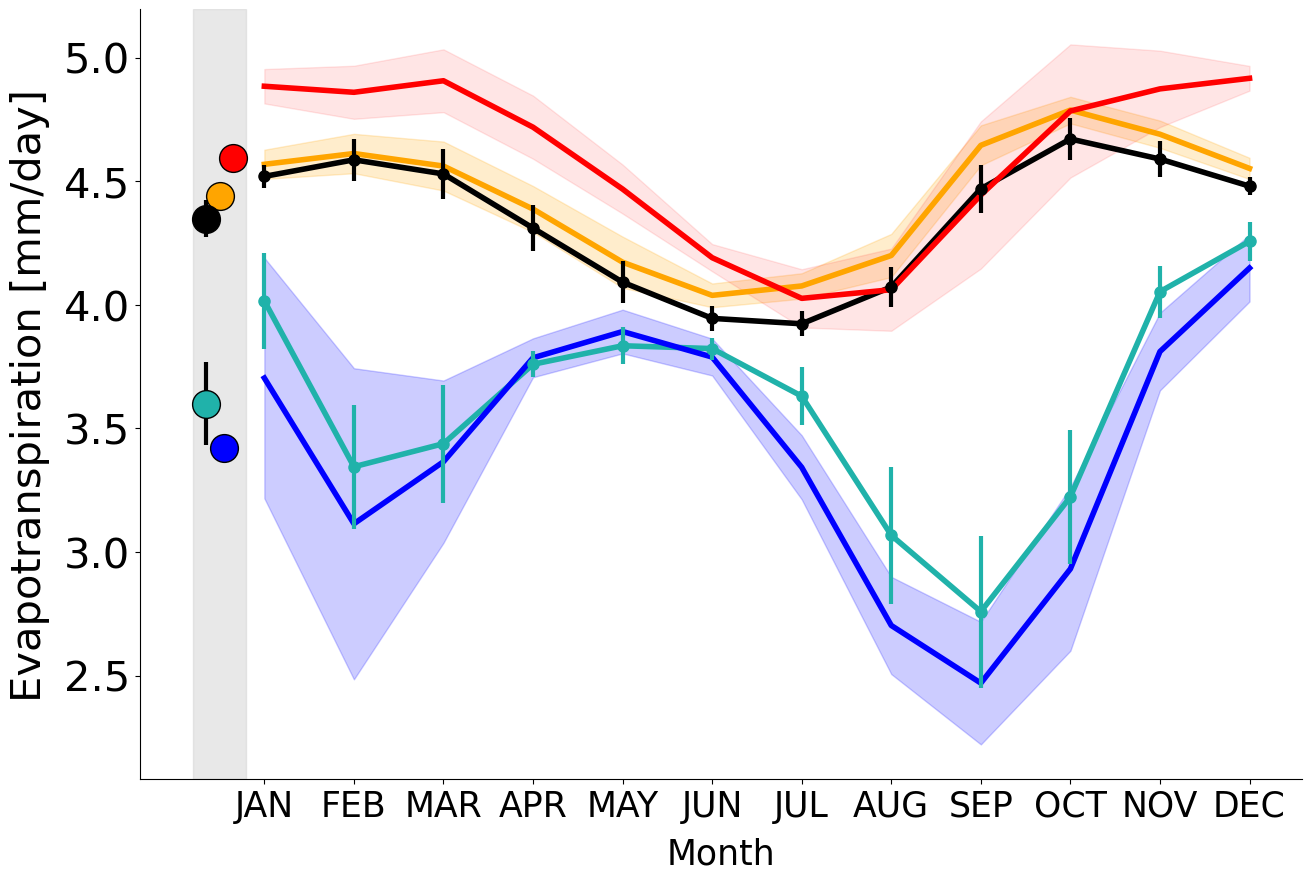

In [54]:
fig, ax = plt.subplots(figsize=(15,10))
month = [1,2,3,4,5,6,7,8,9,10,11,12]
# AMIP
plt.plot(month, hfls_ctl_amz_month, c='black',linewidth=4)
plt.plot(month, hfls_4co2_amz_month, c='orange',linewidth=4) #short time
plt.plot(month, hfls_p4k_amz_month, c='red',linewidth=4) # long time
# NGC4
plt.plot(month, hfls_ngcs_amz_month, c='lightseagreen',linewidth=4) # long time
plt.plot(month, hfls_ngce_amz_month, c='blue',linewidth=4) # long time

# standard deviation
ctl_mean = hfls_ctl_amz_month
ctl_std = hfls_ctl_amz_mon_std
co2_mean = hfls_4co2_amz_month
co2_std = hfls_4co2_amz_mon_std
p4k_mean = hfls_p4k_amz_month
p4k_std = hfls_p4k_amz_mon_std

ngcs_mean = hfls_ngcs_amz_month
ngcs_std = hfls_ngc_amz_mon_std
ngce_mean = hfls_ngce_amz_month
ngce_std = hfls_ngce_amz_mon_std

month = [1,2,3,4,5,6,7,8,9,10,11,12]

plt.errorbar(month, ctl_mean, ctl_std, linestyle='None', marker='o', markersize='8', linewidth=3, c='black')
plt.fill_between(month, co2_mean-co2_std, co2_mean+co2_std, color='orange', alpha=0.2)
plt.fill_between(month, p4k_mean-p4k_std, p4k_mean+p4k_std, color='red', alpha=0.1)

plt.errorbar(month, ngcs_mean, ngcs_std, linestyle='None', marker='o', markersize='8', linewidth=3, c='lightseagreen')
plt.fill_between(month, ngce_mean-ngce_std, ngce_mean+ngce_std, color='blue', alpha=0.2)
#plt.fill_between(hfls_ctl_amz_month.month, ngce_mean-ngce_std, ngce_mean+ngce_std, color='blue', alpha=0.1)

#plt.scatter(1,6.98, c=right, marker='o', s=150)
plt.errorbar(0.35,4.3495975,yerr=0.07379343, c='black', ecolor='black', marker='o', markersize='20', markeredgecolor='black', linewidth=3, zorder=10) #, s=150) # CTL with Climatology error bar
plt.errorbar(0.5,4.4414864,yerr=0, c='orange', marker='o', markeredgecolor='black', markersize='20', zorder=1)
plt.errorbar(0.65,4.595128,yerr=0, c='red', marker='o', markeredgecolor='black', markersize='20', zorder=2)

plt.errorbar(0.35,3.6008253,yerr=0.16790056, c='lightseagreen', ecolor='black', marker='o', markeredgecolor='black', markersize='20', linewidth=3, zorder=12)
plt.errorbar(0.55,3.4216163,yerr=0, c='blue', marker='o', markeredgecolor='black', markersize='20')
#plt.errorbar(0.5,5.23,yerr=0, c='lightcoral', marker='o', markeredgecolor='black', markersize='20')
#plt.errorbar(0.5,4.96,yerr=0, c='darkred', marker='o', markeredgecolor='black', markersize='20')

#plt.axvline(x=0.2, ymin=0.4, ymax=0.7, color='black', linestyle='--', linewidth=2)
#plt.axvline(x=0.8, ymin=0.4, ymax=0.7, color='black', linestyle='--', linewidth=2)
ax.axvspan(0.2, 0.8, alpha=0.5, color='lightgrey')

#plt.xticks(fontsize=30)
plt.yticks(fontsize=30,family='Arial')
ax.set_ylabel('Evapotranspiration [mm/day]',fontsize=30, labelpad = 10,family='Arial')
ax.set_xlabel('Month',fontsize=25, labelpad = 10)
#plt.xlabel('Difference hfls [mm/day]',fontsize=25, labelpad = 20)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],fontsize=25,family='Arial')
#plt.ylim(2,6)
ax.spines[['right', 'top']].set_visible(False)

#fig.savefig('./hfls_exp.png', transparent=True)

_amazon masking: calculate %_

In [36]:
p4k_percentage =  (hfls_p4k.isel(cell=is_amazon).mean(dim=('time','cell')) - hfls_ctl.isel(cell=is_amazon).mean(dim=('time','cell'))) / dx_ctl.pr.isel(cell=is_amazon).mean(dim=('time','cell'))/86400*100
co2_percentage =  (hfls_4co2.isel(cell=is_amazon).mean(dim=('time','cell')) - hfls_ctl.isel(cell=is_amazon).mean(dim=('time','cell'))) / dx_ctl.pr.isel(cell=is_amazon).mean(dim=('time','cell'))/86400*100

In [37]:
ngc_percentage =  (hfls_ngc_end.isel(cell=is_amazon_ngc).mean(dim=('time','cell')) - hfls_ngc_start.isel(cell=is_amazon_ngc).mean(dim=('time','cell'))) / dx_ngc_start.pr.isel(cell=is_amazon_ngc).mean(dim=('time','cell'))/86400*100

In [96]:
ifs_percentage = (lh_ifs_end.where(amazon(dx_ifs).compute(), drop=True).mean(dim=('month','value')) - lh_ifs_start.where(amazon(dx_ifs).compute(), drop=True).mean(dim=('month','value'))) / pr_ifs_start_month.where(amazon(dx_ifs).compute(), drop=True).mean(('month','value'))*100

In [38]:
print(p4k_percentage.values, co2_percentage.values)
print(ngc_percentage.values)
#print(ifs_percentage.values)

3.648628517433449 1.3700156035246671
-3.7607744004991317


## Moisture convergence (mm/day)

In [21]:
convg_ctl = dx_ctl.pr*3600*24 - hfls_ctl
convg_p4k = dx_p4k.pr*3600*24 - hfls_p4k
convg_4co2 = dx_4co2.pr*3600*24 - hfls_4co2

In [41]:
is_amazon = get_amazon_index(nside=egh.get_nside(data_ctl))
convg_ctl_amz = convg_ctl.isel(cell=is_amazon)  # 1979-1997
convg_p4k_amz = convg_p4k.isel(cell=is_amazon) # 1979-1993
convg_4co2_amz = convg_4co2.isel(cell=is_amazon) # 1980-1994

In [22]:
convg_ngc_start = dx_ngc_start.pr*3600*24 - hfls_ngc_start
convg_ngc_end = dx_ngc_end.pr*3600*24 - hfls_ngc_end

In [43]:
# NGC4
is_amazon_ngc = get_amazon_index(nside=egh.get_nside(dx_ngc))
convg_ngc_start_amz = convg_ngc_start.isel(cell=is_amazon_ngc)
convg_ngc_end_amz = convg_ngc_end.isel(cell=is_amazon_ngc)

_Monthly convergence_

In [44]:
convg_ctl_amz_month = convg_ctl_amz.groupby('time.month').mean('time').mean('cell').values
convg_p4k_amz_month = convg_p4k_amz.groupby('time.month').mean('time').mean('cell').values
convg_4co2_amz_month = convg_4co2_amz.groupby('time.month').mean('time').mean('cell').values

In [45]:
convg_ngcs_amz_month = convg_ngc_start_amz.groupby('time.month').mean('time').mean('cell').values
convg_ngce_amz_month = convg_ngc_end_amz.groupby('time.month').mean('time').mean('cell').values

In [46]:
convg_ctl_amz_mon_std = convg_ctl_amz.mean('cell').resample(time="1M").mean().groupby("time.month").std("time")
convg_ctl_amz_mon_std.mean().values

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


array(0.46258032, dtype=float32)

In [47]:
convg_ngc_amz_mon_std = convg_ngc_start_amz.mean('cell').resample(time="1M").mean().groupby("time.month").std("time")
convg_ngc_amz_mon_std.mean().values

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


array(0.40131187, dtype=float32)

In [55]:
convg_4co2_amz_mon_std = convg_4co2_amz.mean('cell').resample(time="1M").mean().groupby("time.month").std("time")
convg_p4k_amz_mon_std = convg_p4k_amz.mean('cell').resample(time="1M").mean().groupby("time.month").std("time")

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [56]:
convg_ngce_amz_mon_std = convg_ngc_end_amz.mean('cell').resample(time="1M").mean().groupby("time.month").std("time")

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [84]:
print(convg_ctl_amz_month.mean())
print(convg_4co2_amz_month.mean())
print(convg_p4k_amz_month.mean())
print(convg_ngcs_amz_month.mean())
print(convg_ngce_amz_month.mean())

2.386457
2.567722
2.2772171
1.1626788
1.0468794


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

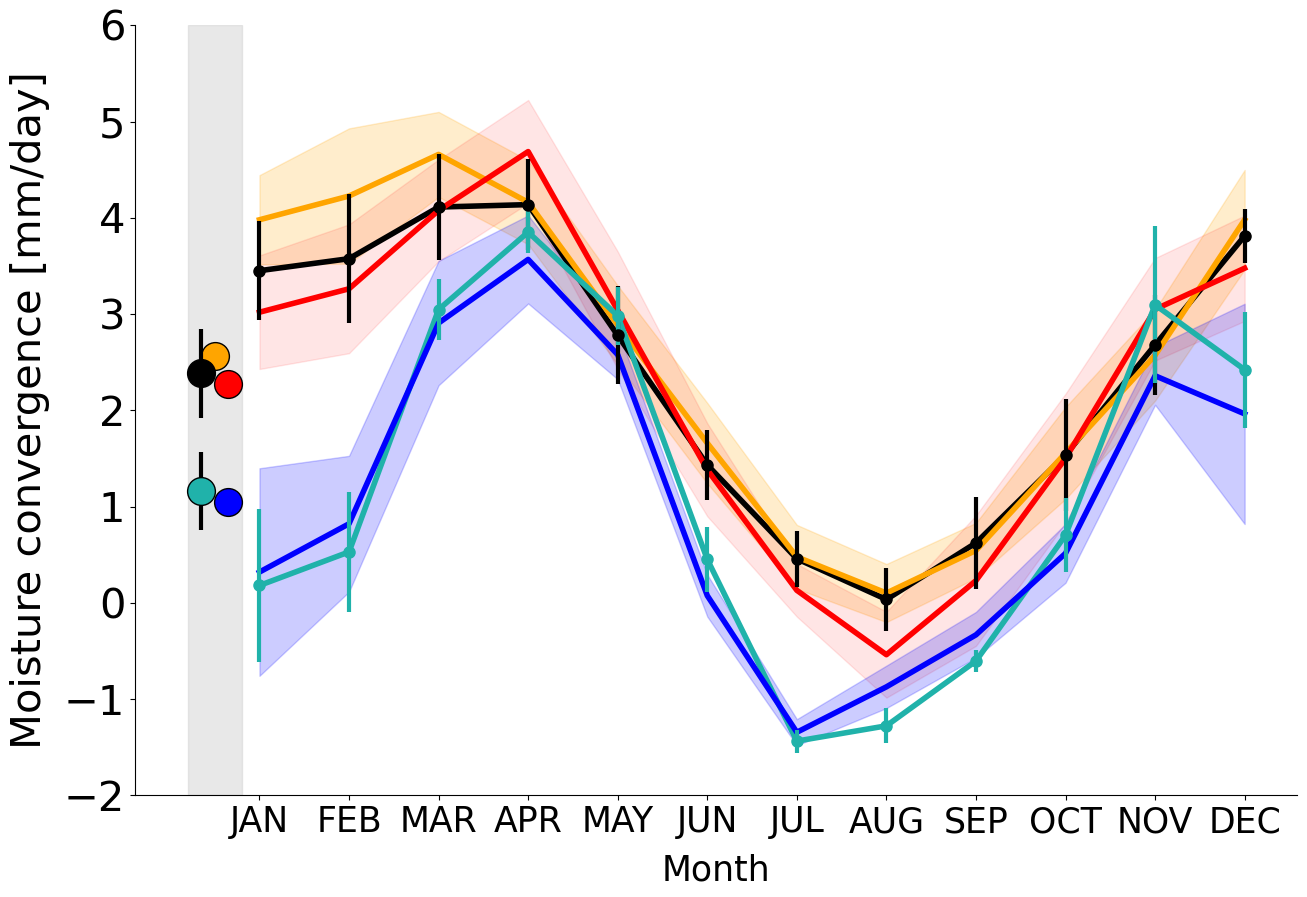

In [57]:
fig, ax = plt.subplots(figsize=(15,10))
month = [1,2,3,4,5,6,7,8,9,10,11,12]
# AMIP
plt.plot(month, convg_ctl_amz_month, c='black',linewidth=4)
plt.plot(month, convg_4co2_amz_month, c='orange',linewidth=4) #short time
plt.plot(month, convg_p4k_amz_month, c='red',linewidth=4) # long time
# NGC4
plt.plot(month, convg_ngcs_amz_month, c='lightseagreen',linewidth=4) # long time
plt.plot(month, convg_ngce_amz_month, c='blue',linewidth=4) # long time

# standard deviation
ctl_mean = convg_ctl_amz_month
ctl_std = convg_ctl_amz_mon_std
co2_mean = convg_4co2_amz_month
co2_std = convg_4co2_amz_mon_std
p4k_mean = convg_p4k_amz_month
p4k_std = convg_p4k_amz_mon_std

ngcs_mean = convg_ngcs_amz_month
ngcs_std = convg_ngc_amz_mon_std
ngce_mean = convg_ngce_amz_month
ngce_std = convg_ngce_amz_mon_std

month = [1,2,3,4,5,6,7,8,9,10,11,12]

plt.errorbar(month, ctl_mean, ctl_std, linestyle='None', marker='o', markersize='8', linewidth=3, c='black')
plt.fill_between(month, co2_mean-co2_std, co2_mean+co2_std, color='orange', alpha=0.2)
plt.fill_between(month, p4k_mean-p4k_std, p4k_mean+p4k_std, color='red', alpha=0.1)

plt.errorbar(month, ngcs_mean, ngcs_std, linestyle='None', marker='o', markersize='8', linewidth=3, c='lightseagreen')
plt.fill_between(month, ngce_mean-ngce_std, ngce_mean+ngce_std, color='blue', alpha=0.2)
#plt.fill_between(convg_ctl_amz_month.month, ngce_mean-ngce_std, ngce_mean+ngce_std, color='blue', alpha=0.1)

#plt.scatter(1,6.98, c=right, marker='o', s=150)
plt.errorbar(0.35,2.386457,yerr=0.46258032, c='black', ecolor='black', marker='o', markersize='20', markeredgecolor='black', linewidth=3, zorder=10) #, s=150) # CTL with Climatology error bar
plt.errorbar(0.5,2.567722,yerr=0, c='orange', marker='o', markeredgecolor='black', markersize='20', zorder=1)
plt.errorbar(0.65,2.2772171,yerr=0, c='red', marker='o', markeredgecolor='black', markersize='20', zorder=2)

plt.errorbar(0.35,1.1626788,yerr=0.40131187, c='lightseagreen', ecolor='black', marker='o', markeredgecolor='black', markersize='20', linewidth=3, zorder=12)
plt.errorbar(0.65,1.0468794,yerr=0, c='blue', marker='o', markeredgecolor='black', markersize='20')
#plt.errorbar(0.5,5.23,yerr=0, c='lightcoral', marker='o', markeredgecolor='black', markersize='20')
#plt.errorbar(0.5,4.96,yerr=0, c='darkred', marker='o', markeredgecolor='black', markersize='20')

#plt.axvline(x=0.2, ymin=0.4, ymax=0.7, color='black', linestyle='--', linewidth=2)
#plt.axvline(x=0.8, ymin=0.4, ymax=0.7, color='black', linestyle='--', linewidth=2)
ax.axvspan(0.2, 0.8, alpha=0.5, color='lightgrey')

#plt.xticks(fontsize=30)
plt.yticks(fontsize=30,family='Arial')
ax.set_ylabel('Moisture convergence [mm/day]',fontsize=30, labelpad = 10,family='Arial')
ax.set_xlabel('Month',fontsize=25, labelpad = 10)
#plt.xlabel('Difference convg [mm/day]',fontsize=25, labelpad = 20)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],fontsize=25,family='Arial')
plt.ylim(-2,6)
ax.spines[['right', 'top']].set_visible(False)

#fig.savefig('./convg_exp.png', transparent=True)

_amazon masking: calculate %_

In [43]:
p4k_percentage =  (convg_p4k.isel(cell=is_amazon).mean(dim=('time','cell')) - convg_ctl.isel(cell=is_amazon).mean(dim=('time','cell'))) / dx_ctl.pr.isel(cell=is_amazon).mean(dim=('time','cell')) / 86400 *100
co2_percentage =  (convg_4co2.isel(cell=is_amazon).mean(dim=('time','cell')) - convg_ctl.isel(cell=is_amazon).mean(dim=('time','cell'))) / dx_ctl.pr.isel(cell=is_amazon).mean(dim=('time','cell')) / 86400 *100

In [46]:
ngc_percentage =  (convg_ngc_end.isel(cell=is_amazon_ngc).mean(dim=('time','cell')) - convg_ngc_start.isel(cell=is_amazon_ngc).mean(dim=('time','cell'))) / dx_ngc_start.pr.isel(cell=is_amazon).mean(dim=('time','cell')) / 86400 *100

In [101]:
ifs_percentage = (convg_ifs_end.where(amazon(dx_ifs).compute(), drop=True).mean(dim=('month','value')) - convg_ifs_start.where(amazon(dx_ifs).compute(), drop=True).mean(dim=('month','value'))) / pr_ifs_start_month.where(amazon(dx_ifs).compute(), drop=True).mean(dim=('month','value'))*100

In [47]:
print(p4k_percentage.values, co2_percentage.values)
print(ngc_percentage.values)
#print(ifs_percentage.values)

-1.6404351128472223 2.6689746997974537
-2.451059412073206


## 3. Seasonal precipitation changes

_monthly mean_

In [23]:
# AMIP
pr_ctl_month = data_ctl.pr.groupby('time.month').mean('time') *86400
pr_p4k_month = dx_p4k.pr.groupby('time.month').mean('time') *86400
pr_4co2_month = dx_4co2.pr.groupby('time.month').mean('time') *86400

In [24]:
# ngc
pr_ngc_start_month = dx_ngc_start.pr.groupby('time.month').mean('time') *86400
pr_ngc_end_month = dx_ngc_end.pr.groupby('time.month').mean('time') *86400

_amazon masking: calculate %_

In [ ]:
p4k_percentage =  (pr_p4k_month.isel(cell=is_amazon).mean(dim='month') - pr_ctl_month.isel(cell=is_amazon).mean(dim='month')) / pr_ctl_month.isel(cell=is_amazon).mean('month')*100
co2_percentage =  (pr_4co2_month.isel(cell=is_amazon).mean(dim='month') - pr_ctl_month.isel(cell=is_amazon).mean(dim='month')) / pr_ctl_month.isel(cell=is_amazon).mean('month')*100

In [59]:
print(p4k_percentage.mean('cell').values, co2_percentage.mean('cell').values)

1.4549313942556412 4.362552846231304


In [ ]:
ngc_percentage =  (convg_ngc_end.isel(cell=is_amazon_ngc).mean(dim='time') - convg_ngc_start.isel(cell=is_amazon_ngc).mean(dim='time')) / pr_ngc_start_month.isel(cell=is_amazon_ngc).mean('month')*100

In [ ]:
print(p4k_percentage.mean('cell').values, co2_percentage.mean('cell').values)
print(ngc_percentage.mean('cell').values)
print(ifs_percentage.mean('value').values)

-1.8229801282060432 2.8699746253432084
-2.238647542415577
-6.899617222323361


### Evapotranspiration

In [26]:
hfls_ctl_month = hfls_ctl.groupby('time.month').mean('time')
hfls_4co2_month = hfls_4co2.groupby('time.month').mean('time')
hfls_p4k_month = hfls_p4k.groupby('time.month').mean('time')

In [27]:
hfls_ngcs_month = hfls_ngc_start.groupby('time.month').mean('time')
hfls_ngce_month = hfls_ngc_end.groupby('time.month').mean('time')

### moisture convergence

In [34]:
convg_ctl_month = pr_ctl_month - hfls_ctl_month
convg_4co2_month = pr_4co2_month - hfls_4co2_month
convg_p4k_month = pr_p4k_month - hfls_p4k_month

In [65]:
convg_ctl_month

<xarray.DataArray (cell: 786432)> Size: 3MB
dask.array<sub, shape=(786432,), dtype=float32, chunksize=(81920,), chunktype=numpy.ndarray>
Coordinates:
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
    healpix  int64 8B 0
Attributes:
    grid_mapping:  healpix

In [35]:
convg_ngcs_month = pr_ngc_start_month - hfls_ngcs_month
convg_ngce_month = pr_ngc_end_month - hfls_ngce_month

_ploting_

In [28]:
BrBG_new = colormap_create('BrBG',21,10,11)

In [ ]:
da = (convg_p4k_month.mean(dim='month') - convg_ctl_month.mean(dim='month')) / pr_ctl_month.mean(dim='month') * 100
plot_map_healpix(da, ax=None, title=None, colorbar=True, cmap=BrBG_new, nest=True, vmin=-20, vmax=20, space=11, extend='both', latmin=-60, latmax=20, lonmin=-100, lonmax=-20)

In [43]:
experiments = {
    "pr": {
        "A": pr_4co2_month.mean(dim="month"),
        "B": pr_p4k_month.mean(dim="month"),
        "C": pr_ngc_end_month.mean(dim="month"),
    },
    "et": {
        "A": hfls_4co2_month.mean(dim="month"),
        "B": hfls_p4k_month.mean(dim="month"),
        "C": hfls_ngce_month.mean(dim="month"),
    },
    "conv": {
        "A": convg_4co2_month.mean(dim="month"),
        "B": convg_p4k_month.mean(dim="month"),
        "C": convg_ngce_month.mean(dim="month"),
    }
}

control = {
    "pr": {
        "A": pr_ctl_month.mean(dim="month"),
        "B": pr_ctl_month.mean(dim="month"),
        "C": pr_ngc_start_month.mean(dim="month"),
    },
    "et": {
        "A": hfls_ctl_month.mean(dim="month"),
        "B": hfls_ctl_month.mean(dim="month"),
        "C": hfls_ngcs_month.mean(dim="month"),
    },
    "conv": {
        "A": convg_ctl_month.mean(dim="month"),
        "B": convg_ctl_month.mean(dim="month"),
        "C": convg_ngcs_month.mean(dim="month"),
    }
}

denomi = {
    "pr": {
        "A": pr_ctl_month.mean(dim="month"),
        "B": pr_ctl_month.mean(dim="month"),
        "C": pr_ngc_start_month.mean(dim="month"),
    },
    "et": {
        "A": pr_ctl_month.mean(dim="month"),
        "B": pr_ctl_month.mean(dim="month"),
        "C": pr_ngc_start_month.mean(dim="month"),
    },
    "conv": {
        "A": pr_ctl_month.mean(dim="month"),
        "B": pr_ctl_month.mean(dim="month"),
        "C": pr_ngc_start_month.mean(dim="month"),
    }
}

In [44]:
# variable names in your xarray datasets
var_order = ["pr", "et", "conv"]
exp_order = ["C","A","B"]
row_labels = {
    "pr": "Precipitation",
    "et": "Evapotranspiration",
    "conv": "Convergence"
}

# ---------------------------------------------------
# 2. Percentage change function
# ---------------------------------------------------
def percent_change(exp_da, ctrl_da, denomi_da, threshold=1e-10):
    """
    Compute percentage change relative to control.
    Small control values are masked to avoid huge values.
    """
    return (exp_da - ctrl_da) / denomi_da * 100

# compute all percentage changes
changes = {}

for var in var_order:
    changes[var] = {}
    for exp in exp_order:
        changes[var][exp] = percent_change(
            experiments[var][exp],
            control[var][exp],
            denomi[var][exp]
        )

In [49]:
# ---------------------------------------------------
# 1. Bounds
# ---------------------------------------------------
bounds = np.arange(-20, 22, 2)

# ---------------------------------------------------
# 2. Use MANY colors (safe approach)
# ---------------------------------------------------
base_cmap = plt.get_cmap("BrBG")

colors = base_cmap(np.linspace(0, 1, 256))  # plenty of colors

# ---------------------------------------------------
# 3. Convert to ListedColormap
# ---------------------------------------------------
cmap = mcolors.ListedColormap(colors)

# ---------------------------------------------------
# 4. BoundaryNorm
# ---------------------------------------------------
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend="both")

# ---------------------------------------------------
# 5. Force white in [-2, 2]
# ---------------------------------------------------
mid_low = np.where(bounds == -2)[0][0]
mid_high = np.where(bounds == 2)[0][0]

# map bin index → color index
idx_low = int(mid_low / (len(bounds)-1) * cmap.N)
idx_high = int(mid_high / (len(bounds)-1) * cmap.N)

cmap.colors[idx_low:idx_high] = [1, 1, 1, 1]

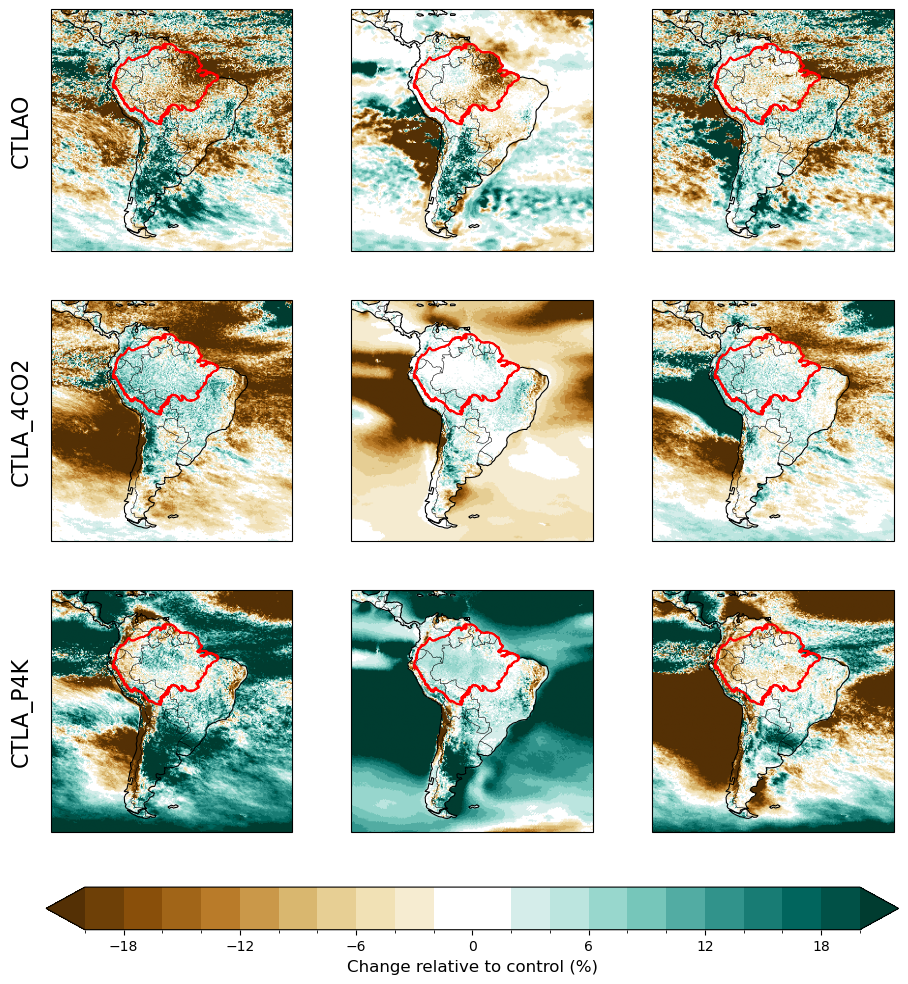

In [56]:
# Amazon contour
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES

# ---------------------------------------------------
# 4. Plot 3 x 3 panel
# ---------------------------------------------------
projection = ccrs.PlateCarree(central_longitude=225)
fig, axes = plt.subplots(
    3, 3,
    figsize=(11, 12),
    subplot_kw={"projection": projection},
)

# columns and rows
col_order = ["pr", "et", "conv"]
row_order = ["C", "A", "B"]

col_labels = {
    "pr": r'$\Delta$P',
    "et": r'$\Delta$E',
    "conv": r'$\Delta$C'
}

row_labels = {
    "C": "CTLAO",
    "A": "CTLA_4CO2",
    "B": "CTLA_P4K"
}

pc = None 

for i, exp in enumerate(row_order):        # rows
    for j, var in enumerate(col_order):    # columns
        ax = axes[i, j]
        da = changes[var][exp]

        ax.set_extent([-100, -20, -60, 20], ccrs.PlateCarree())
        pc = egh.healpix_show(da, ax=ax, cmap=cmap, norm=norm, nest=True)

        ax.coastlines(resolution="110m", linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)

        kw = {'levels': [-1], 'colors': ['red'], 'linestyles': ['solid']}
        AMZ_BD.plot.contour(
            ax=ax,
            transform=ccrs.PlateCarree(),
            **kw
        )

        # column titles
       # if i == 0:
       #     ax.set_title(col_labels[var], fontsize=13)

        # row labels
        if j == 0:
            ax.text(
                -0.12, 0.5, row_labels[exp],
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=16
            )

# ---------------------------------------------------
# 5. Shared colorbar
# ---------------------------------------------------
cbar = fig.colorbar(
    pc,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.06,
    extend="both"
)
cbar.set_label("Change relative to control (%)", fontsize=12)

plt.show()

## Time tendency of prw

_Daily_

In [81]:
# Daily
prw_ctl_amz = dx_ctl_amz.prw
prw_4co2_amz = dx_4co2_amz.prw
prw_p4k_amz = dx_p4k_amz.prw

In [67]:
# Daily
prw_ngcs_amz = dx_ngc_start_amz.prw
prw_ngce_amz = dx_ngc_end_amz.prw

In [ ]:
# time tendency (d(prw)/d(day))
ctl_time_diff = prw_ctl_amz['time'].diff('time') / np.timedelta64(1, 'D')
ctl_vapor_diff = prw_ctl_amz.diff('time')
ctl_prw_derivative = ctl_vapor_diff / ctl_time_diff
ctl_prw_derivative['time'] = prw_ctl_amz['time'][1:]

In [83]:
# time tendency
ngcs_time_diff = prw_ngcs_amz['time'].diff('time') / np.timedelta64(1, 'D')
ngcs_vapor_diff = prw_ngcs_amz.diff('time')
ngcs_prw_derivative = ngcs_vapor_diff / ngcs_time_diff
ngcs_prw_derivative['time'] = prw_ngcs_amz['time'][1:]

In [86]:
ctl_prw_derivative_monthly = ctl_prw_derivative.resample(time="1M").mean().groupby("time.month").mean("time")
ngcs_prw_derivative_monthly = ngcs_prw_derivative.resample(time="1M").mean().groupby("time.month").mean("time")

In [ ]:
xarray_names = ['ctl_prw_derivative','ngcs_prw_derivative','ctl_prw_derivative_monthly','ngcs_prw_derivative_monthly']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [88]:
print(ctl_prw_derivative_f.mean(),ngcs_prw_derivative_f.mean())

3.141096782220597e-05 0.002549070922331546


In [89]:
print(ctl_prw_derivative_monthly_f.mean(),ngcs_prw_derivative_monthly_f.mean())

2.7289811122090364e-06 0.0030659742066254337
